# Phase 7 · Bloc 7.0 — Suivi des expériences avec MLflow : carnet de travail

**Rôle de ce carnet.** Avant de régler et de comparer les modèles, chaque entraînement est désormais **tracé**.
Ce carnet exécute la chaîne de quatre runs demandée — forêt et XGBoost en autolog, régression logistique tracée
à la main, recherche par grille —, les compare, enregistre le meilleur au registre, le recharge et l'utilise.

**Principe.** MLflow est un **journal et une vitrine**, pas une source de vérité : le manifeste, `resultats/` et
les tests de non-régression font foi. MLflow les **relie** — et la fin de ce carnet vérifie qu'il dit la même
chose qu'eux.

| Décision | Choix |
|---|---|
| Stockage | SQLite local, chemin absolu (`config.URI_SUIVI`) ; `make mlflow` ouvre l'interface |
| Comparaison | Métriques **hors pli** du protocole, communes à tous les runs ; jamais celles de l'autolog |
| Registre | Alias `challenger` ; `champion` est réservé au modèle retenu en fin de phase 7 |
| Prédiction | Scoring de fonctionnement de l'échantillon ; le jeu de test reste scellé |

In [1]:
# --- Environment ---------------------------------------------------------------------
import importlib.util
import json
import sys
from pathlib import Path

RACINE = Path.cwd()
for candidat in [RACINE, *RACINE.parents]:
    if (candidat / "src" / "churn_saas").is_dir():
        RACINE = candidat
        sys.path.insert(0, str(candidat / "src"))
        break

import mlflow
import pandas as pd

from churn_saas import config
from churn_saas.notebook import afficher_source, afficher_tableau
from churn_saas.packaging import configurer_suivi, journaliser_modele, uri_suivi

configurer_suivi()
print("Magasin MLflow :", uri_suivi())


def outil(nom):
    specification = importlib.util.spec_from_file_location(nom, RACINE / "tools" / f"{nom}.py")
    module = importlib.util.module_from_spec(specification)
    specification.loader.exec_module(module)
    return module

Magasin MLflow : sqlite:////tmp/mlf7b/t.db


/home/claude/ai4me/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. La chaîne de quatre runs

Le code est celui de `tools/pipeline_mlflow.py`. Trois précautions y sont écrites :

- **un seul autolog actif à la fois**, désactivé entre les runs, pour qu'aucune chaîne ne soit journalisée deux fois ;
- **la chaîne complète** — imputation, encodage, modèle — est journalisée avec sa signature, jamais l'estimateur
  seul : un modèle sans son prétraitement ne saurait pas prédire sur les données préparées ;
- **les métriques hors pli du protocole** (25 plis de la phase 5) sont ajoutées à chaque run, sous les mêmes clés.

In [2]:
# --- How a model is logged: the whole pipeline, with its signature ---------------------------
afficher_source(journaliser_modele)

**Source — `churn_saas.packaging.suivi.journaliser_modele`**

```python
def journaliser_modele(modele: Any, X_exemple: pd.DataFrame, nom: str = "modele") -> None:
    """Log a fitted pipeline - preprocessing included - with its signature and an example.

    The whole pipeline is logged, never the bare estimator: a model registered without
    its imputation and encoding could not score prepared data (training-serving skew).
    The signature is inferred on rows holding missing values, so the registry accepts
    them at prediction time.

    Serialised with cloudpickle: MLflow 3's default (skops) rejects the numpy and
    xgboost types these pipelines hold unless each is declared trusted. The trust model
    is the one of the joblib artefacts already used by the project: models are only ever
    loaded from the project's own store.
    """
    mlflow = configurer_suivi()
    if mlflow is None:
        return
    from mlflow import sklearn as mlflow_sklearn
    from mlflow.models import infer_signature

    exemple = pd.concat([X_exemple[X_exemple.isna().any(axis=1)].head(25), X_exemple.head(25)])
    signature = infer_signature(exemple, modele.predict_proba(exemple)[:, 1])
    mlflow_sklearn.log_model(
        modele,
        name=nom,
        signature=signature,
        input_example=X_exemple.head(3),
        serialization_format="cloudpickle",
    )

```

'def journaliser_modele(modele: Any, X_exemple: pd.DataFrame, nom: str = "modele") -> None:\n    """Log a fitted pipeline - preprocessing included - with its signature and an example.\n\n    The whole pipeline is logged, never the bare estimator: a model registered without\n    its imputation and encoding could not score prepared data (training-serving skew).\n    The signature is inferred on rows holding missing values, so the registry accepts\n    them at prediction time.\n\n    Serialised with cloudpickle: MLflow 3\'s default (skops) rejects the numpy and\n    xgboost types these pipelines hold unless each is declared trusted. The trust model\n    is the one of the joblib artefacts already used by the project: models are only ever\n    loaded from the project\'s own store.\n    """\n    mlflow = configurer_suivi()\n    if mlflow is None:\n        return\n    from mlflow import sklearn as mlflow_sklearn\n    from mlflow.models import infer_signature\n\n    exemple = pd.concat([X_exem

2026/10/02 21:25:43 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/10/02 21:25:43 INFO mlflow.store.db.utils: Updating database tables


Durée estimée : environ 6 min sur Intel(R) Core(TM) i5-6300U CPU @ 2.40GHz (26 régressions, 258 forêts ; temps mesurés par make ressources).


2026/10/02 21:27:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/10/02 21:27:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


...

2026/10/02 21:31:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Successfully registered model 'churn-saas'.
2026/10/02 21:31:34 WARNING mlflow.tracking._model_registry.fluent: Run with id 5a238ae6ca9d424e910a4d1a53607bdf has no artifacts at artifact path 'modele', registering model based on models:/m-a12c194cddfb4611a39c32dc5b38d2f8 instead


Created version '1' of model 'churn-saas'.


runName,pr_auc_cv,rappel_haut_cv,roc_auc_cv,erreur_calibration_cv
regression logistique · manuel,0.7933,0.3305,0.8915,0.1143
grille foret · GridSearchCV autolog,0.7738,0.3173,0.8820,0.0445
foret · sklearn.autolog,0.7727,0.3177,0.8830,0.1053
xgboost · xgboost.autolog,0.7722,0.3214,0.8792,0.0802


Meilleur run : régression logistique · manuel — enregistré au registre, version 1


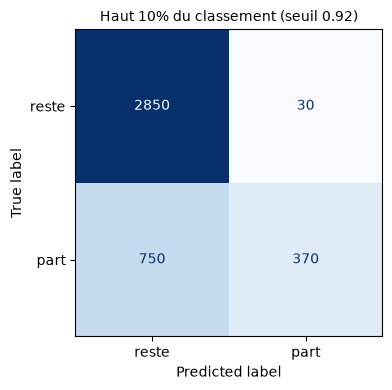

In [3]:
# --- Run the four tracked runs (about seven minutes on one core, grid included) ---------------
chaine = outil("pipeline_mlflow")
bilan = chaine.executer(avec_grille=True)
afficher_tableau(pd.DataFrame(bilan["comparaison"]).rename(columns=lambda c: c.split(".")[-1]),
                 titre="mlflow.search_runs() — classement par PR-AUC hors pli")
print(f"Meilleur run : {bilan['meilleur']} — enregistré au registre, version {bilan['version_registre']}")

**Lecture.** La **régression logistique** reste en tête (PR-AUC 0,793), devant la forêt réglée par la grille, la
forêt par défaut et XGBoost, groupés autour de 0,77. Les chiffres retrouvent ceux des phases 5 et 6 : la chaîne
MLflow ne change rien aux résultats, elle les trace. La grille ne fait presque rien gagner à la forêt en PR-AUC,
mais **divise par deux son erreur de calibration** — un constat à exploiter dans la suite de la phase 7.

## 2. Le piège de l'autolog

L'autolog journalise ses propres métriques, calculées **sur les lignes d'entraînement**.

In [4]:
# --- What autolog measures, against what the protocol measures -----------------------------------
runs = mlflow.search_runs(experiment_names=[f"{config.PREFIXE_EXPERIENCES}/phase7-chaine-mlflow"])
runs = runs[runs["metrics.pr_auc_cv"].notna()].drop_duplicates("tags.mlflow.runName")
colonnes = {"tags.mlflow.runName": "run", "metrics.training_recall_score": "recall d'entraînement (autolog)",
            "metrics.rappel_haut_cv": "rappel haut 10 % hors pli (protocole)"}
afficher_tableau(runs[[c for c in colonnes if c in runs]].rename(columns=colonnes).round(3),
                 titre="Le même modèle, mesuré sur ce qu'il a appris ou sur ce qu'il n'a pas vu")

run,recall d'entraînement (autolog),rappel haut 10 % hors pli (protocole)
grille foret · GridSearchCV autolog,0.890,0.317
regression logistique · manuel,NaN,0.331
xgboost · xgboost.autolog,NaN,0.321
foret · sklearn.autolog,0.919,0.318


**Lecture.** Sur ses lignes d'entraînement, la forêt « trouve » plus de 90 % des départs ; hors pli, au haut du
classement, elle en trouve moins d'un tiers. Classés sur les métriques de l'autolog, les runs auraient désigné le
modèle qui **apprend par cœur**. D'où la règle : la comparaison ne lit que les clés hors pli communes (registre,
E-703). La régression logistique, tracée à la main, n'a pas de métrique d'entraînement : c'est voulu.

## 3. Le registre : charger et utiliser le meilleur modèle

Le modèle chargé depuis le registre (`models:/churn-saas@challenger`) score les 50 comptes de l'échantillon, en
passant par la même chaîne de préparation que le lot mensuel. **Ce n'est pas une évaluation** : ces comptes ont
été vus à l'entraînement ou appartiennent au test, qui reste scellé.

In [5]:
# --- Loaded from the registry: same probabilities as the model in memory ---------------------------
print(f"{bilan['comptes_scores']} comptes scorés — probabilités identiques au modèle en mémoire : "
      f"{bilan['registre_identique_au_modele_en_memoire']}")
print("Cinq premières probabilités :", bilan["probabilites"])
version = mlflow.MlflowClient().get_model_version_by_alias(config.MODELE_REGISTRE, config.ALIAS_CANDIDAT)
print(f"Registre : {config.MODELE_REGISTRE}@{config.ALIAS_CANDIDAT} → version {version.version}, "
      f"run {version.run_id[:8]}")

50 comptes scorés — probabilités identiques au modèle en mémoire : True
Cinq premières probabilités : [0.7541, 0.6177, 0.0935, 0.0194, 0.9991]
Registre : churn-saas@challenger → version 1, run 5a238ae6


## 4. Le lignage, et la cohérence avec les sources de vérité

Trois vérifications font de MLflow un outil de **validation**, pas seulement de journalisation : le jeu vu par
MLflow est celui du manifeste ; les phases 5 et 6 retracées redonnent les chiffres figés ; le modèle du registre
prédit comme le modèle en mémoire (ci-dessus).

In [6]:
# --- Data lineage, and the replayed history of phases 5 and 6 -------------------------------------
from churn_saas.donnees import charger_manifeste
from churn_saas.features import executer_pipeline
from churn_saas.packaging import tracer_donnees

manifeste = charger_manifeste(RACINE / "data" / "manifeste_v1.0.json")
resultat = executer_pipeline(config.FICHIER_COMPLET, config.FICHIER_CATALOGUE)
run_donnees = mlflow.get_run(tracer_donnees(resultat.gold, resultat.journal, manifeste,
                                            profil=resultat.X.describe(include="all").T))
empreinte = manifeste["jeux_derives"]["jeux"]["gold"]["empreinte_contenu"]
print("Empreinte du gold vue par MLflow = manifeste :",
      run_donnees.inputs.dataset_inputs[0].dataset.digest == empreinte[:32])

retrace = outil("retracer_mlflow")
phase6 = retrace.retracer_phase6(mlflow, {"phase": "6"})
reference = json.loads((RACINE / "resultats" / "reference_baseline.json").read_text(encoding="utf-8"))
afficher_tableau(pd.DataFrame({
    "retracé dans MLflow": phase6,
    "référence figée": {n: b["moyenne"]["PR-AUC"] for n, b in reference["baselines"].items()},
}).round(6).reset_index(names="baseline"), titre="Phase 6 retracée : PR-AUC identiques")

Empreinte du gold vue par MLflow = manifeste : True


baseline,retracé dans MLflow,référence figée
naïve,0.280000,0.280000
règle métier,0.530174,0.530174
régression logistique,0.793300,0.793300


## 5. Relancer sans dupliquer, et la durée annoncée confrontée à la durée mesurée (bloc 7.0 bis)

Chaque exécution de la chaîne est **un run parent** ; la comparaison ne lit que ses enfants, et une nouvelle
version n'est enregistrée que si le code, les données ou la configuration ont changé. La seconde exécution
ci-dessous, sans rien changer, ne crée donc **aucune version**. Avant de démarrer, chaque outil annonce sa durée,
calculée avec les temps mesurés sur le poste (`config/ressources_poste.toml`) ; MLflow enregistre la durée réelle
de chaque run.

In [7]:
# --- A second execution changes nothing in the registry ------------------------------------------
second = chaine.executer(avec_grille=False)
print(f"Seconde exécution : version {second['version_registre']} — "
      f"nouvelle version : {second['nouvelle_version']}")

# --- Announced against measured durations ---------------------------------------------------------
from churn_saas.modelisation import estimer_duree
from churn_saas.packaging import durees_des_runs

with open(config.FICHIER_RESSOURCES, "rb") as flux:
    import tomllib
    temps = tomllib.load(flux)["mesures"]
annonce = {"regression logistique · manuel": estimer_duree(temps, entrainements_lr=26),
           "foret · sklearn.autolog": estimer_duree(temps, entrainements_foret=26),
           "grille foret · GridSearchCV autolog": estimer_duree(temps, entrainements_foret=206)}
mesure = durees_des_runs(f"{config.PREFIXE_EXPERIENCES}/phase7-chaine-mlflow")
mesure = mesure[mesure["run"].isin(annonce)].groupby("run")["secondes"].median()
afficher_tableau(pd.DataFrame({"annoncée (s)": pd.Series(annonce).round(0),
                               "mesurée par MLflow (s)": mesure}).reset_index(names="run"),
                 titre="Durée annoncée (temps du poste de développement) et durée mesurée")

Durée estimée : environ 70 s sur Intel(R) Core(TM) i5-6300U CPU @ 2.40GHz (26 régressions, 52 forêts ; temps mesurés par make ressources).


2026/10/02 21:33:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/10/02 21:33:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/10/02 21:33:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/10/02 21:33:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/10/02 21:33:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/10/02 21:33:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Seconde exécution : version 1 — nouvelle version : False


run,annoncée (s),mesurée par MLflow (s)
foret · sklearn.autolog,33.0,98.65
grille foret · GridSearchCV autolog,265.0,227.80
regression logistique · manuel,3.0,4.90


**Lecture.** L'annonce repose sur les temps mesurés **sur le portable de développement** ; la mesure, sur la
machine qui exécute ce carnet. Sur le portable, les deux colonnes doivent rester du même ordre ; ailleurs, l'écart
mesure simplement la différence de machine. La grille, qui entraîne ses forêts sur une seule couche parallèle
(`config.N_JOBS`), est le poste le plus coûteux.

## 5. Journal de bord du bloc 7.0

**Décisions.** Suivi local en SQLite à chemin absolu ; comparaison sur les métriques hors pli ; alias
`challenger` ; scoring de fonctionnement sur l'échantillon ; XGBoost en troisième famille (`xgboost-cpu`).

**Problèmes rencontrés et corrections.**
- MLflow 3 refuse par défaut de sérialiser nos chaînes (format skops) : `cloudpickle` retenu (E-702).
- Le paquet `xgboost` tirait les bibliothèques CUDA : `xgboost-cpu` (E-701).
- Les entiers *nullables* auraient fait refuser les valeurs manquantes par la signature : convertis en décimaux à
  l'entrée du modèle, à l'identique à l'entraînement et au lot mensuel.
- L'étiquette « modifications non committées » ignorait les fichiers nouveaux : corrigé.

**Tests** (campagne `phase7`) : sans MLflow, le suivi est un no-op silencieux ; aucun test n'écrit dans le magasin
du projet ; le registre prédit comme le modèle en mémoire ; l'empreinte vue par MLflow est celle du manifeste ; la
phase 6 retracée redonne la référence figée.

**Suite de la phase 7.** Régler et comparer les modèles contre la référence, calibrer le retenu (D-07), l'évaluer
une seule fois sur le jeu de test, puis lui donner l'alias `champion`.